The choice of 0.25 was based on the worcap work

tokamak


In [1]:
import pandas as pd

# File paths
path_synth_025 = "../data/test/test_series_150.csv"
path_heat_flux_iter = "data/jorek/heat_flux_iter.csv"

# Read CSV
df_heat_flux_iter = pd.read_csv(path_heat_flux_iter)
df_synth_025 = pd.read_csv(path_synth_025)

print(df_heat_flux_iter.head())
print(df_synth_025.head())


   Time-step  Amplitude
0          0   0.000573
1          1   0.759309
2          2   1.412255
3          3   0.800641
4          4   1.455755
        raw  normalized  peak  peak_threshold  p_value
0  0.041842    0.000866     0        0.434575     0.33
1  0.074649    0.002625     0        0.434575     0.33
2  0.074649    0.002625     0        0.434575     0.33
3  0.141257    0.006197     0        0.434575     0.33
4  0.276491    0.013448     0        0.434575     0.33


In [2]:
x_heat_flux_iter = df_heat_flux_iter["Amplitude"].values
x_synth_025 = df_synth_025["raw"].values


In [3]:
import numpy as np


def normalize_minmax(x):
    min_train = x.min()
    max_train = x.max()

    return (x - min_train) / (max_train - min_train)

x_heat_flux_iter = normalize_minmax(x_heat_flux_iter)
x_synth_025 = normalize_minmax(x_synth_025)

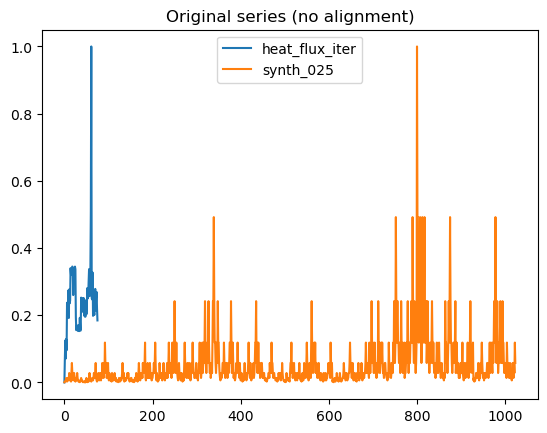

In [4]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(x_heat_flux_iter, label="heat_flux_iter")
plt.plot(x_synth_025, label="synth_025")
plt.legend()
plt.title("Original series (no alignment)")
plt.show()


In [5]:
from statsmodels.tsa.stattools import acf

acf_heat_flux_iter = acf(x_heat_flux_iter, nlags=200)
acf_synth_025 = acf(x_synth_025, nlags=200)


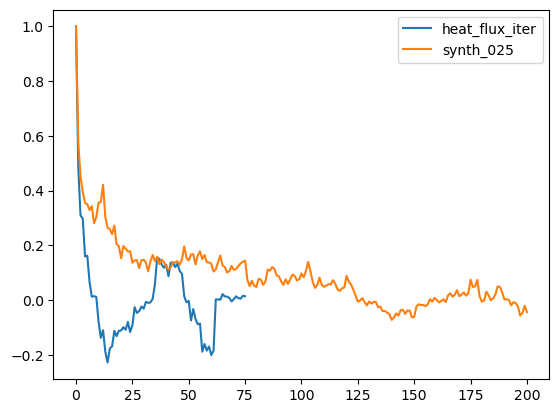

In [6]:
plt.plot(acf_heat_flux_iter, label="heat_flux_iter")
plt.plot(acf_synth_025, label="synth_025")
plt.legend()
plt.show()


In [7]:
import numpy as np

def lag_decorrelation(acf_values, threshold=0.05, min_lag=1):
    """
    Retorna o primeiro lag onde |ACF| < threshold
    """
    for lag in range(min_lag, len(acf_values)):
        if np.abs(acf_values[lag]) < threshold:
            return lag
    return len(acf_values) - 1


In [8]:
from statsmodels.tsa.stattools import acf

acf_heat_flux_iter = acf(x_heat_flux_iter, nlags=200)
acf_synth_025 = acf(x_synth_025, nlags=200)


In [9]:
lag_heat_flux_iter = lag_decorrelation(acf_heat_flux_iter, threshold=0.05)
lag_synth_025 = lag_decorrelation(acf_synth_025, threshold=0.05)

print("Lag heat_flux_iter:", lag_heat_flux_iter)
print("Lag synth_025:", lag_synth_025)


Lag heat_flux_iter: 7
Lag synth_025: 80


In [10]:
k = lag_synth_025 / lag_heat_flux_iter
print("Estimated k:", k)

k_int = int(round(k))
print("Rounded k:", k_int)


Estimated k: 11.428571428571429
Rounded k: 11


In [95]:
import numpy as np
from scipy.interpolate import interp1d

t_heat_flux_iter = np.arange(len(x_heat_flux_iter))
t_new = np.linspace(0, len(x_heat_flux_iter)-1, int(np.round(len(x_heat_flux_iter)*1)))

interp = interp1d(t_heat_flux_iter, x_heat_flux_iter, kind='linear')
x_heat_flux_iter_rs = interp(t_new)


In [96]:
interp = interp1d(t_heat_flux_iter, x_heat_flux_iter, kind='cubic')


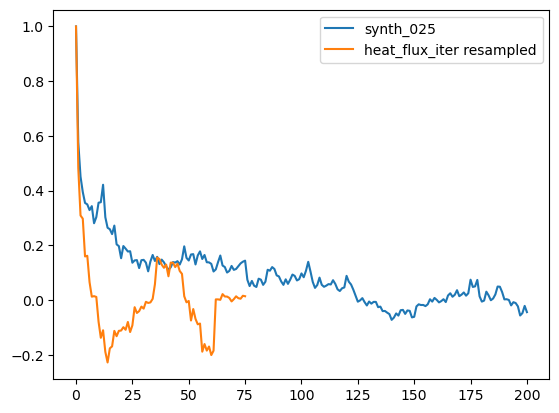

In [97]:
acf_new = acf(x_heat_flux_iter_rs, nlags=200)

plt.plot(acf_synth_025, label="synth_025")
plt.plot(acf_new, label="heat_flux_iter resampled")
plt.legend()
plt.show()


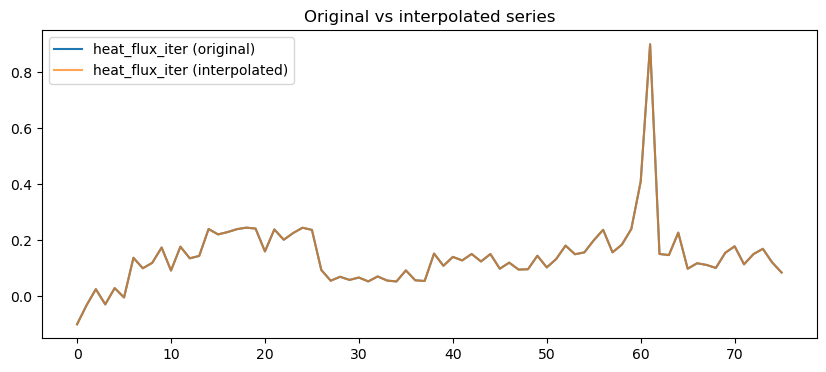

In [98]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(x_heat_flux_iter - 0.1, label='heat_flux_iter (original)')
plt.plot(x_heat_flux_iter_rs - 0.1, label='heat_flux_iter (interpolated)', alpha=0.7)
plt.legend()
plt.title('Original vs interpolated series')
plt.show()


In [99]:
import pandas as pd

df = pd.DataFrame({
    'Time-step': t_new,
    'Amplitude': x_heat_flux_iter_rs
})

df.to_csv('data/jorek/heat_flux_iter_resampled.csv', index=False)


sdo


In [57]:
import pandas as pd

path_synth_025_sdo = "../data/test/test_series_200.csv"
path_sdo = "data/sdo/sun_lightcurve.csv"

# Read CSV
df_sdo = pd.read_csv(path_sdo)
df_synth_025_sdo = pd.read_csv(path_synth_025_sdo)

print(df_sdo.head())
print(df_synth_025_sdo.head())


  Time-step  Amplitude
0     00:08   0.364134
1     00:18   0.361608
2     00:27   0.361187
3     00:37   0.344980
4     00:47   0.371290
        raw  normalized  peak  peak_threshold  p_value
0  0.551058    0.028170     0        0.434575     0.33
1  1.108511    0.058060     0        0.434575     0.33
2  0.551058    0.028170     0        0.434575     0.33
3  0.276491    0.013448     0        0.434575     0.33
4  1.108511    0.058060     0        0.434575     0.33


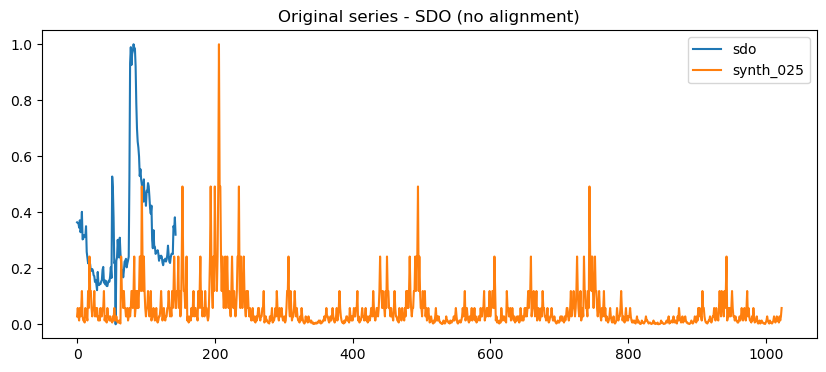

In [58]:
x_sdo = df_sdo["Amplitude"].values
x_synth_025_sdo = df_synth_025_sdo["raw"].values

# Normalize
x_sdo = normalize_minmax(x_sdo)
x_synth_025_sdo = normalize_minmax(x_synth_025_sdo)

# Plot original series
plt.figure(figsize=(10, 4))
plt.plot(x_sdo, label="sdo")
plt.plot(x_synth_025_sdo, label="synth_025")
plt.legend()
plt.title("Original series - SDO (no alignment)")
plt.show()


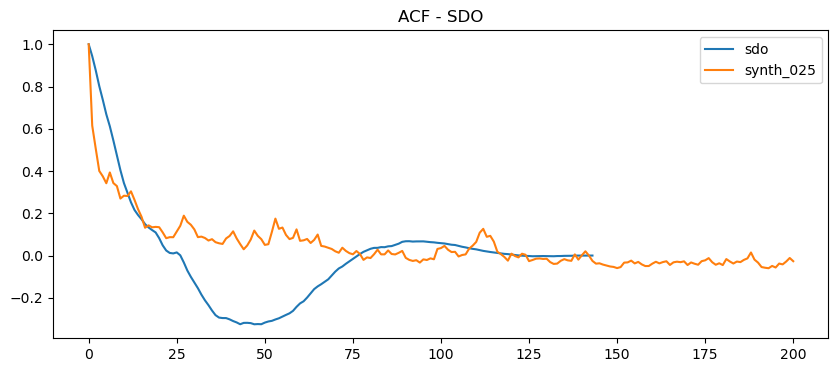

Lag sdo: 21
Lag synth_025: 44
Estimated k (SDO): 2.0952380952380953
Rounded k (SDO): 2


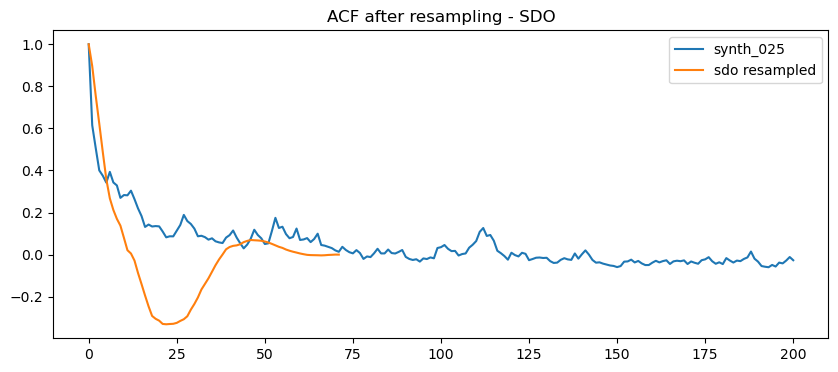

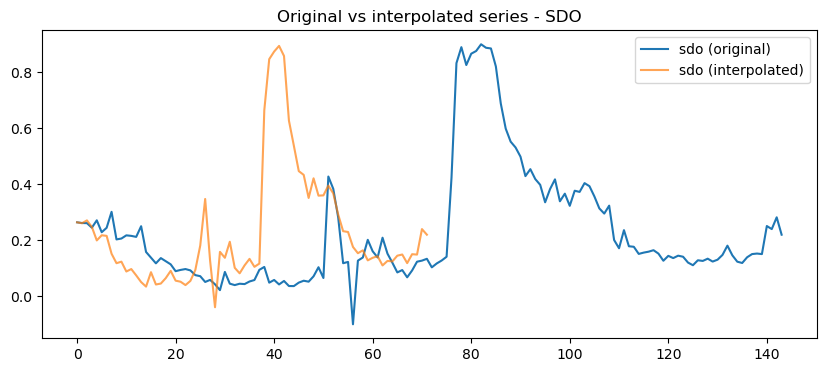

Resampled SDO saved!


In [63]:
# Calculate ACF
acf_sdo = acf(x_sdo, nlags=200)
acf_synth_025_sdo = acf(x_synth_025_sdo, nlags=200)

# Plot ACF
plt.figure(figsize=(10, 4))
plt.plot(acf_sdo, label="sdo")
plt.plot(acf_synth_025_sdo, label="synth_025")
plt.legend()
plt.title("ACF - SDO")
plt.show()

# Calculate decorrelation lags
lag_sdo = lag_decorrelation(acf_sdo, threshold=0.05)
lag_synth_025_sdo = lag_decorrelation(acf_synth_025_sdo, threshold=0.05)

print("Lag sdo:", lag_sdo)
print("Lag synth_025:", lag_synth_025_sdo)

# Calculate k
k_sdo = lag_synth_025_sdo / lag_sdo
print("Estimated k (SDO):", k_sdo)

k_int_sdo = int(round(k_sdo))
print("Rounded k (SDO):", k_int_sdo)

# Resampling SDO
t_sdo = np.arange(len(x_sdo))
t_new_sdo = np.linspace(0, len(x_sdo)-1, int(np.round(len(x_sdo)*0.5)))

interp_sdo = interp1d(t_sdo, x_sdo, kind='cubic')
x_sdo_rs = interp_sdo(t_new_sdo)

# ACF of resampled SDO
acf_sdo_rs = acf(x_sdo_rs, nlags=200)

plt.figure(figsize=(10, 4))
plt.plot(acf_synth_025_sdo, label="synth_025")
plt.plot(acf_sdo_rs, label="sdo resampled")
plt.legend()
plt.title("ACF after resampling - SDO")
plt.show()

# Plot original vs interpolated series
plt.figure(figsize=(10, 4))
plt.plot(x_sdo - 0.1, label='sdo (original)')
plt.plot(x_sdo_rs - 0.1, label='sdo (interpolated)', alpha=0.7)
plt.legend()
plt.title('Original vs interpolated series - SDO')
plt.show()

# Save resampled SDO
df_sdo_rs = pd.DataFrame({
    'Time-step': t_new_sdo,
    'Amplitude': x_sdo_rs
})

df_sdo_rs.to_csv('data/sdo/sdo_time_series_resampled.csv', index=False)
print("Resampled SDO saved!")
